# 04_01 Classification - LogisticRegression

Train and evaluate Logistic Regression on `features/classification_fe`.

[COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]
- Muc tieu nghiep vu: Train Logistic Regression va hien thi ket qua danh gia ro rang tren notebook.
- Muc tieu ky thuat: Su dung split train/val/test 70/15/15 va ve confusion matrix + bang metric.

In [1]:
from pathlib import Path
import json
from pyspark.sql import SparkSession
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

spark = (SparkSession.builder.appName('04_01_lr').master('local[2]').config('spark.sql.shuffle.partitions','16').getOrCreate())
spark.sparkContext.setLogLevel('WARN')
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
FEATURE_DIR = PROJECT_ROOT / 'data' / 'processed' / 'features'
MODEL_DIR = PROJECT_ROOT / 'models' / 'classification' / 'logistic_regression'
METRIC_DIR = PROJECT_ROOT / 'reports' / 'model_metrics'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
train_df = spark.read.parquet(str(FEATURE_DIR / 'classification_train')).select('order_id','label','features').dropna()
val_df = spark.read.parquet(str(FEATURE_DIR / 'classification_val')).select('order_id','label','features').dropna()
test_df = spark.read.parquet(str(FEATURE_DIR / 'classification_test')).select('order_id','label','features').dropna()

26/04/05 18:02:01 WARN Utils: Your hostname, Genius-Macbook.local resolves to a loopback address: 127.0.0.1; using 10.178.74.160 instead (on interface en0)
26/04/05 18:02:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/05 18:02:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/05 18:02:03 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [ ]:
# --- Oversample minority class (class 1) to handle class imbalance ---
_c0 = train_df.filter(train_df['label'] == 0)
_c1 = train_df.filter(train_df['label'] == 1)
_n0, _n1 = _c0.count(), _c1.count()
print(f'Before oversampling: class_0={_n0}, class_1={_n1}, ratio={_n0/_n1:.2f}')
train_df = _c0.unionAll(_c1.sample(withReplacement=True, fraction=_n0/_n1, seed=42))
print(f'After oversampling: {train_df.count()} rows')

26/04/05 18:02:15 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/05 18:02:15 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


val_f1=0.8529  val_acc=0.8703  val_precision=0.8648  val_recall=0.8703
test_f1=0.8612  test_acc=0.8778  test_precision=0.8710  test_recall=0.8778
{'model_family': 'classification', 'model_name': 'LogisticRegression', 'val_f1': 0.8529493041165997, 'val_accuracy': 0.8702735317779565, 'val_precision': 0.8648395519079983, 'val_recall': 0.8702735317779565, 'f1': 0.8612057824347514, 'accuracy': 0.8778492893537141, 'precision': 0.8710393005359083, 'recall': 0.8778492893537141, 'test_f1': 0.8612057824347514, 'test_accuracy': 0.8778492893537141, 'test_precision': 0.8710393005359083, 'test_recall': 0.8778492893537141, 'train_rows': 69609, 'val_rows': 14916, 'test_rows': 14916}


,model_family,model_name,val_f1,val_accuracy,val_precision,val_recall,f1,accuracy,precision,recall,test_f1,test_accuracy,test_precision,test_recall,train_rows,val_rows,test_rows
0,classification,LogisticRegression,0.852949,0.870274,0.86484,0.870274,0.861206,0.877849,0.871039,0.877849,0.861206,0.877849,0.871039,0.877849,69609,14916,14916


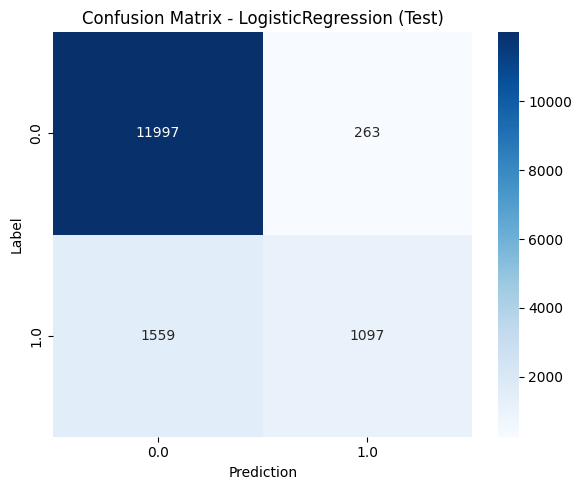

366

In [2]:
model = LogisticRegression(featuresCol='features', labelCol='label', regParam=0.05, elasticNetParam=0.0, maxIter=100)
tuning_grid = (
    ParamGridBuilder()
    .addGrid(model.regParam, [0.01, 0.05, 0.1])
    .addGrid(model.maxIter, [80, 120])
    .build()
)
tuning_eval = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1')
tvs = TrainValidationSplit(
    estimator=model,
    estimatorParamMaps=tuning_grid,
    evaluator=tuning_eval,
    trainRatio=0.8,
    seed=42,
)
tvs_model = tvs.fit(train_df)
lr_model = tvs_model.bestModel
pred_val = lr_model.transform(val_df)
pred_test = lr_model.transform(test_df)
val_f1 = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1').evaluate(pred_val)
val_acc = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy').evaluate(pred_val)
val_precision = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedPrecision').evaluate(pred_val)
val_recall    = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedRecall').evaluate(pred_val)
test_f1 = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1').evaluate(pred_test)
test_acc = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy').evaluate(pred_test)
test_precision = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedPrecision').evaluate(pred_test)
test_recall    = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedRecall').evaluate(pred_test)
metrics = {
    'model_family': 'classification',
    'model_name': 'LogisticRegression',
    'val_f1': float(val_f1),
    'val_accuracy': float(val_acc),
    'val_precision': float(val_precision),
    'val_recall':    float(val_recall),
    'f1': float(test_f1),
    'accuracy': float(test_acc),
    'precision': float(test_precision),
    'recall':    float(test_recall),
    'test_f1': float(test_f1),
    'test_accuracy': float(test_acc),
    'test_precision': float(test_precision),
    'test_recall':    float(test_recall),
    'train_rows': train_df.count(),
    'val_rows': val_df.count(),
    'test_rows': test_df.count(),
}
print(f"val_f1={val_f1:.4f}  val_acc={val_acc:.4f}  val_precision={val_precision:.4f}  val_recall={val_recall:.4f}")
print(f"test_f1={test_f1:.4f}  test_acc={test_acc:.4f}  test_precision={test_precision:.4f}  test_recall={test_recall:.4f}")
print(metrics)
display(pd.DataFrame([metrics]))
cm_pdf = pred_test.groupBy('label', 'prediction').count().toPandas()
if not cm_pdf.empty:
    cm_table = cm_pdf.pivot(index='label', columns='prediction', values='count').fillna(0).sort_index().sort_index(axis=1)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_table, annot=True, fmt='.0f', cmap='Blues')
    plt.title('Confusion Matrix - LogisticRegression (Test)')
    plt.xlabel('Prediction')
    plt.ylabel('Label')
    plt.tight_layout()
    plt.show()
best_params = {
    'regParam': float(lr_model.getRegParam()),
    'maxIter': int(lr_model.getMaxIter()),
}
tuning_report = {
    'model_family': 'classification',
    'model_name': 'LogisticRegression',
    'tuning_method': 'TrainValidationSplit',
    'metric': 'f1',
    'avgMetrics': [float(x) for x in tvs_model.validationMetrics],
    'bestParams': best_params,
}
lr_model.write().overwrite().save(str(MODEL_DIR))
(METRIC_DIR / 'classification_logistic_regression.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
(METRIC_DIR / 'tuning_classification_logistic_regression.json').write_text(json.dumps(tuning_report, indent=2), encoding='utf-8')